In [1]:
import os
import torch
import random
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from pycocotools.coco import COCO

In [2]:
BATCH_SIZE = 2

In [3]:
class COCODataset(Dataset):
    def __init__(self, split, transform=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        path_map = {"train": "train-300", "valid": "validation-300", "test": "test-30"}
        self.split_path = path_map[split]
        self.coco = COCO(os.path.join(self.split_path, "labels.json"))
        self.image_ids = list(sorted(self.coco.imgs.keys()))
        self.transform = transform
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image_details = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.split_path, "data", image_details["file_name"])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        
        annot_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annot_ids)

        boxes, masks, labels = [], [], []
        for annotation in annotations:
            box = annotation["bbox"]
            try:
                masks.append(torch.tensor(self.coco.annToMask(annotation), dtype=torch.uint8))
            except IndexError:
                continue
            boxes.append([int(box[0]), int(box[1]), int(box[0] + box[2]), int(box[1] + box[3])])
            labels.append(annotation["category_id"])

        masks = torch.stack(masks, dim=0)
        boxes = torch.tensor(boxes)
        target = {}
        
        target["boxes"] = boxes
        target["masks"] = masks
        target["labels"] = torch.tensor(labels)

        return image, target

In [4]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

transform = Compose([
    ToTensor(),
    Normalize(mean=mean, std=std),
])

train_dataset = COCODataset(split="train", transform=transform)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [5]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
images_, targets_ = next(iter(train_loader))

In [6]:
valid_dataset = COCODataset(split="valid", transform=transform)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, collate_fn=lambda batch: tuple(zip(*batch)))

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!


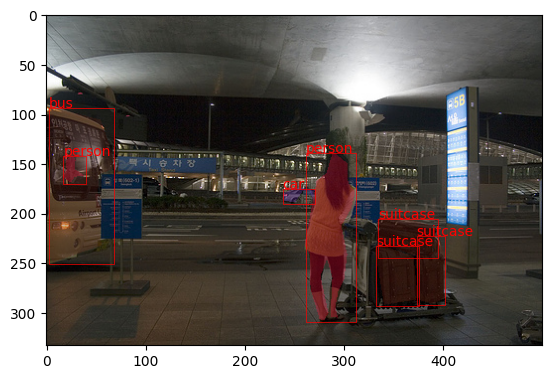

In [7]:
random.seed(42)
colors = [(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for _ in range(len(train_dataset.coco.cats))]

unnormalize = Normalize(
    mean=[-mean[0] / std[0], -mean[1] / std[1], -mean[2] / std[2]],
    std=[1 / std[0], 1 / std[1], 1 / std[2]]
)

def binary_mask_to_transparent(mask, fill_color=(255, 0, 0)):
    transparent_mask = np.zeros((*mask.shape, 4), dtype=np.uint8)
    transparent_mask[..., :3] = fill_color
    transparent_mask[..., 3] = mask * 255
    
    return transparent_mask

def plot_image_and_annotations(image, targets):
    image_ = unnormalize(image.clone())
    plt.imshow(image_.permute(1, 2, 0))

    for box, mask, label in zip(targets["boxes"], targets["masks"], targets["labels"]):
        x1, y1, x2, y2 = box
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=0.5, edgecolor="red"))
        plt.text(x1, y1, train_dataset.coco.loadCats(label.item())[0]["name"], color="red")
        plt.imshow(binary_mask_to_transparent(mask, fill_color=colors[label.item()]), alpha=0.3)

image_, targets_ = train_dataset[1]
plot_image_and_annotations(image_, targets_)

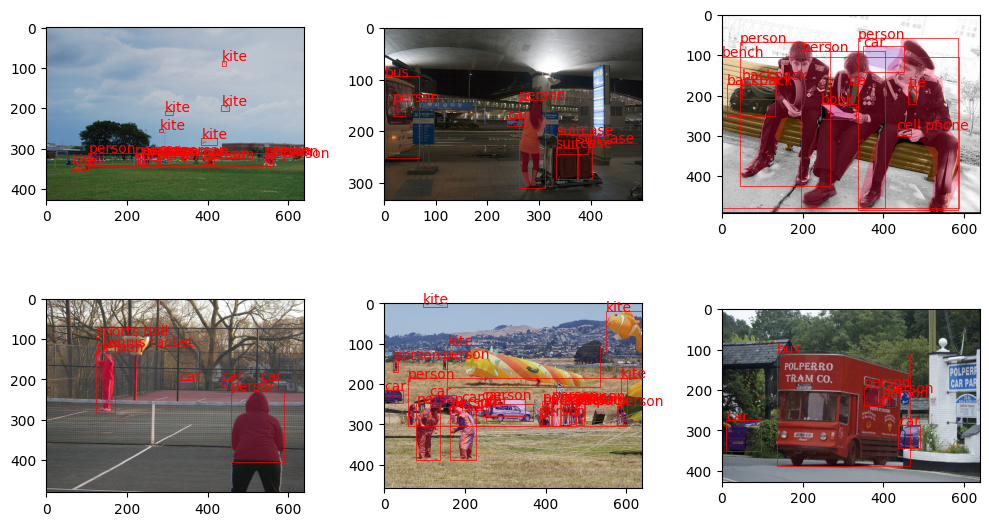

In [8]:
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    image_, target_ = train_dataset[i]
    plot_image_and_annotations(image_, target_)

plt.tight_layout()

In [9]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )

# device = "cpu"
print("Using device:", device)

Using device: cuda


In [10]:
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights

model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights)

train_classes = len(train_dataset.coco.cats)
valid_classes = len(valid_dataset.coco.cats)

num_classes = max((train_classes, valid_classes)) + 1
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

C:\Users\raksh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9)

In [12]:
def train_and_validate(model, train_loader, valid_loader, n_epochs, optimizer):
    total_train_losses = []
    total_valid_losses = []
    for epoch in range(n_epochs):
        # TRAINING
        epoch_train_losses = []
        model.train()
        for batch_num, (images, targets) in enumerate(train_loader):
            images = [image.to(device) for image in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            # print(loss_dict)
            losses = sum(loss for loss in loss_dict.values())
            epoch_train_losses.append(losses.item())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            if batch_num % 25 == 0:
                print(f"[EPOCH {epoch+1}] - [{batch_num}/{len(train_loader)}] - Total Loss: {losses.item():0.5f}")
        
        total_train_losses.append(epoch_train_losses)

        # VALIDATION
        epoch_valid_losses = []
        with torch.no_grad():
            for batch_num, (images, targets) in enumerate(valid_loader):
                images = [image.to(device) for image in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                epoch_valid_losses.append(losses.item())

                if batch_num % 25 == 0:
                    print(f"[EPOCH {epoch+1}] - [VALIDATION ({batch_num}/{len(valid_loader)})] - Total Loss: {sum(epoch_valid_losses)/len(epoch_valid_losses):0.5f}")
            
            total_valid_losses.append(epoch_valid_losses)
    
    return total_train_losses, total_valid_losses

In [13]:
model.to(device)
train_losses, valid_losses = train_and_validate(model,
                                                train_loader,
                                                valid_loader,
                                                n_epochs=30,
                                                optimizer=optimizer)

torch.save(model.state_dict(), "coco_model.pth")
torch.save(train_losses, "train_losses.pth")
torch.save(valid_losses, "valid_losses.pth")

[EPOCH 1] - [0/150] - Total Loss: 6.60424
[EPOCH 1] - [25/150] - Total Loss: 1.41663
[EPOCH 1] - [50/150] - Total Loss: 1.19215
[EPOCH 1] - [75/150] - Total Loss: 1.50426
[EPOCH 1] - [100/150] - Total Loss: 2.02663
[EPOCH 1] - [125/150] - Total Loss: 1.77443
[EPOCH 1] - [VALIDATION (0/150)] - Total Loss: 1.36269
[EPOCH 1] - [VALIDATION (25/150)] - Total Loss: 1.57365
[EPOCH 1] - [VALIDATION (50/150)] - Total Loss: 1.75342
[EPOCH 1] - [VALIDATION (75/150)] - Total Loss: 1.78405
[EPOCH 1] - [VALIDATION (100/150)] - Total Loss: 1.79971
[EPOCH 1] - [VALIDATION (125/150)] - Total Loss: 1.82555
[EPOCH 2] - [0/150] - Total Loss: 1.22891
[EPOCH 2] - [25/150] - Total Loss: 3.24032
[EPOCH 2] - [50/150] - Total Loss: 1.11108
[EPOCH 2] - [75/150] - Total Loss: 1.96435
[EPOCH 2] - [100/150] - Total Loss: 1.74335
[EPOCH 2] - [125/150] - Total Loss: 3.33291
[EPOCH 2] - [VALIDATION (0/150)] - Total Loss: 1.66277
[EPOCH 2] - [VALIDATION (25/150)] - Total Loss: 1.79682
[EPOCH 2] - [VALIDATION (50/150)] 

Text(0.5, 1.0, 'Train Loss')

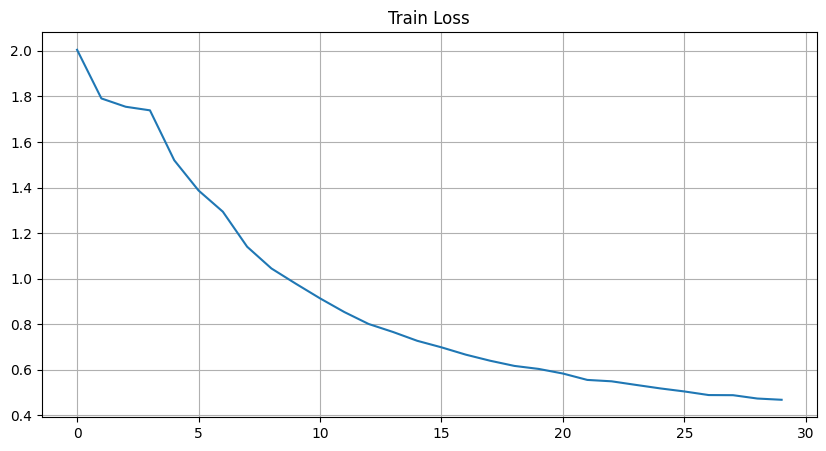

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(np.array(train_losses).mean(axis=-1))
plt.grid("on")
plt.title("Train Loss")

Text(0.5, 1.0, 'Valid Loss')

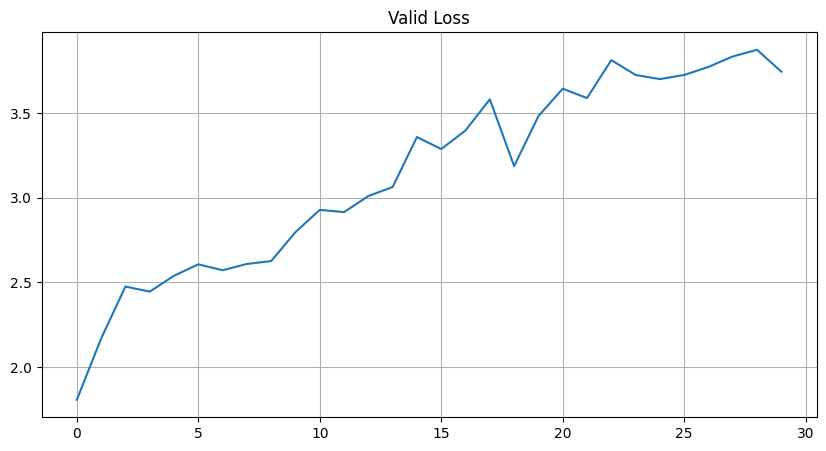

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(np.array(valid_losses).mean(axis=-1))
plt.grid("on")
plt.title("Valid Loss")

Text(0.5, 1.0, 'Train Loss - All Interations')

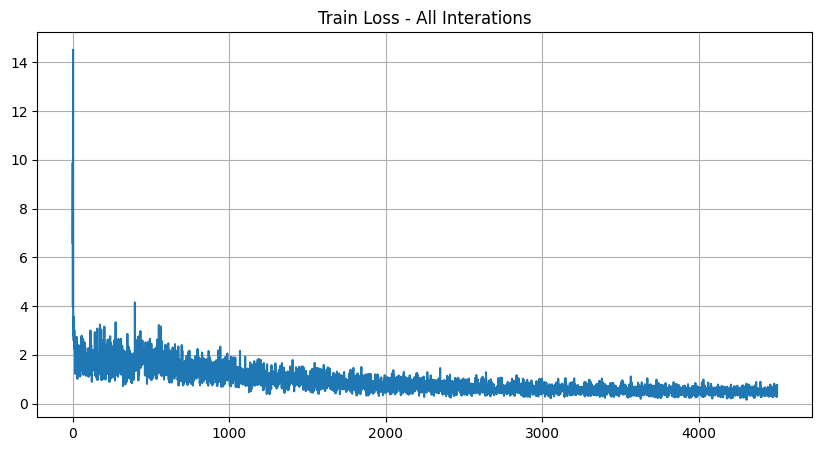

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(np.array(train_losses).ravel())
plt.grid("on")
plt.title("Train Loss - All Interations")

Text(0.5, 1.0, 'Valid Loss - All Iterations')

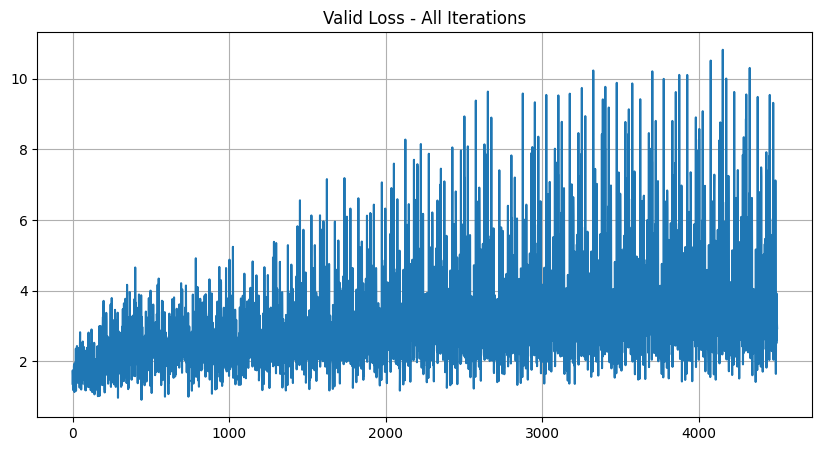

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(np.array(valid_losses).ravel())
plt.grid("on")
plt.title("Valid Loss - All Iterations")